# Problem Statement – Customer Churn Prediction Using XGBoost

- A telecom company wants to identify customers who are likely to leave its services (churn). Customer churn can lead to revenue loss, so the company needs an effective machine learning model to predict high-risk customers.

- The objective of this project is to build an XGBoost Classification model that predicts whether a customer will churn or stay based on their personal, service, billing, and contract information.

In [47]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

In [48]:
df=pd.read_csv("/Users/nidagallusandeep/Downloads/gradient_boosting_customer_churn_10000.csv")

In [49]:
df.head()

,Age,Monthly_Charges,Total_Charges,Tenure_Months,Number_of_Services,Support_Calls,Contract_Length,Payment_Delay_Days,Churn
0,63,61.33,10279.33,32,7,2,24,2,No
1,20,115.96,1713.44,27,1,4,1,20,Yes
2,46,92.05,10890.48,1,2,4,12,17,Yes
3,52,95.26,7126.69,58,4,4,36,15,Yes
4,56,147.00,12255.65,17,7,7,12,13,Yes


In [50]:
df.shape

(10000, 9)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 10000 non-null  int64  
 1   Monthly_Charges     10000 non-null  float64
 2   Total_Charges       10000 non-null  float64
 3   Tenure_Months       10000 non-null  int64  
 4   Number_of_Services  10000 non-null  int64  
 5   Support_Calls       10000 non-null  int64  
 6   Contract_Length     10000 non-null  int64  
 7   Payment_Delay_Days  10000 non-null  int64  
 8   Churn               10000 non-null  object 
dtypes: float64(2), int64(6), object(1)
memory usage: 703.3+ KB


In [16]:
df.columns

Index(['Age', 'Monthly_Charges', 'Total_Charges', 'Tenure_Months',
       'Number_of_Services', 'Support_Calls', 'Contract_Length',
       'Payment_Delay_Days', 'Churn'],
      dtype='object')

In [17]:
df.describe()

,Age,Monthly_Charges,Total_Charges,Tenure_Months,Number_of_Services,Support_Calls,Contract_Length,Payment_Delay_Days
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,43.432400,85.088660,7735.098163,36.625100,4.004500,4.976500,18.295900,15.065500
std,15.027169,37.468756,4148.071109,20.836184,1.987077,3.151181,13.050003,9.013231
min,18.000000,20.040000,502.450000,1.000000,1.000000,0.000000,1.000000,0.000000
25%,30.000000,52.177500,4121.222500,19.000000,2.000000,2.000000,12.000000,7.000000
50%,43.000000,85.860000,7716.620000,37.000000,4.000000,5.000000,24.000000,15.000000
75%,57.000000,117.450000,11327.785000,55.000000,6.000000,8.000000,24.000000,23.000000
max,69.000000,149.950000,14997.600000,72.000000,7.000000,10.000000,36.000000,30.000000


In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.isnull().sum()

Age                   0
Monthly_Charges       0
Total_Charges         0
Tenure_Months         0
Number_of_Services    0
Support_Calls         0
Contract_Length       0
Payment_Delay_Days    0
Churn                 0
dtype: int64

In [20]:
df["Churn"].value_counts()

Churn
Yes    6044
No     3956
Name: count, dtype: int64

# Separate X and y

In [23]:
X = df.drop("Churn", axis=1)

y = df["Churn"].map({
    "No": 0,
    "Yes": 1})

# Train-Test Split

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=0.2,random_state=42)

# Apply XGBoost

In [25]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    eval_metric="logloss")

xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


# Prediction

In [26]:
y_pred = xgb_model.predict(X_test)
print(y_pred[:20])

[0 1 0 0 1 0 0 1 1 1 1 0 0 1 1 1 1 1 1 0]


# Accuracy

In [27]:
accuracy = accuracy_score(y_test, y_pred)
print("XGBoost Accuracy:", accuracy)

XGBoost Accuracy: 0.939625


# Confusion Matrix

In [28]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2948  223]
 [ 260 4569]]


# Classification Report

In [29]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      3171
           1       0.95      0.95      0.95      4829

    accuracy                           0.94      8000
   macro avg       0.94      0.94      0.94      8000
weighted avg       0.94      0.94      0.94      8000



# XGBoost GridSearchCV

In [34]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [2, 3, ...], 'n_estimators': [50, 100, ...], 'subsample': [0.8, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"ver

In [36]:
best_xgb = grid_search.best_estimator_

print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Best CV Score:
0.9325000000000001


In [37]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

              Feature  Importance
1     Monthly_Charges    0.635882
7  Payment_Delay_Days    0.085007
3       Tenure_Months    0.079191
5       Support_Calls    0.062501
6     Contract_Length    0.051870
0                 Age    0.038552
2       Total_Charges    0.024052
4  Number_of_Services    0.022946


# Plot Feature Importance

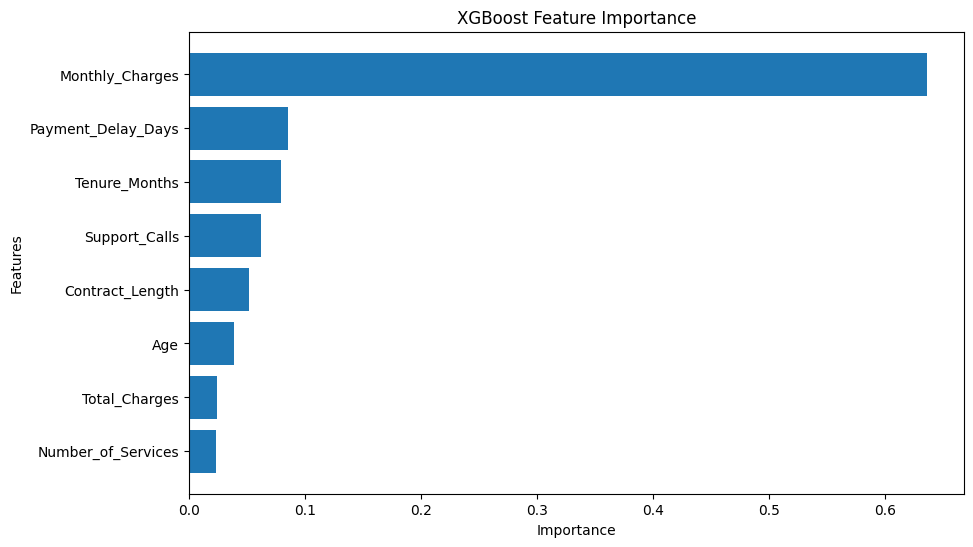

In [38]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(
    importance["Feature"],
    importance["Importance"])

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.show()